# Analyse factorielle des correspondances


Les données ont été produites avec le carnet [Production aléatoire d'observations](production_aleatoire_observations_llm.ipynb)


Il s'agit de données synthétiques sans aucune relation avec la réalité et dont la finalité est uniquement l'apprentissages de méthodes d'analyse. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import sqlite3 as sql

In [2]:
from fanalysis.ca import CA 
from fanalysis.mca import MCA

In [3]:
### Lire le fichier corrigé manuellement – ne pas effacer !

path =  'data/llama3_20250315.csv'

obs = pd.read_csv(path)
obs.set_index('id', inplace=True)
obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media
id,,,,,,
1,39,Other,24147,daily,Rightwing,115
2,81,Male,47296,daily,Rightwing,0
3,60,Male,4991,week-end,Populist,140
4,51,Female,14162,daily,Center,108
5,30,Male,12519,3-4 days a week,Rightwing,171


In [4]:
### Créer une copie indépendante du DataFrame (attention aux copies de variables qui sont seulement des alias) 
# et coder les années de naissance en relation avec un découpage significatif au point de vue heuristique, et modifiable si besion
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

generations = [18, 26, 36, 46, 56, 66, 91]
c_obs = obs.copy(deep=True)
c_obs['generation'] = pd.cut(c_obs['age'], generations, right=False)
c_obs['generation'] = c_obs['generation'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))\
       .astype(dtype='str')
# Inspection
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation
id,,,,,,,
1,39,Other,24147,daily,Rightwing,115,36-45
2,81,Male,47296,daily,Rightwing,0,66-90
3,60,Male,4991,week-end,Populist,140,56-65
4,51,Female,14162,daily,Center,108,46-55
5,30,Male,12519,3-4 days a week,Rightwing,171,26-35


In [5]:
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

classes_revenu = [0,3000, 4500, 6000, 8000, 10000, 12000, 300000]
c_obs['classe_revenu'] = pd.cut(c_obs['monthly_revenue'], classes_revenu, right=False)
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu
id,,,,,,,,
1,39,Other,24147,daily,Rightwing,115,36-45,"[12000, 300000)"
2,81,Male,47296,daily,Rightwing,0,66-90,"[12000, 300000)"
3,60,Male,4991,week-end,Populist,140,56-65,"[4500, 6000)"
4,51,Female,14162,daily,Center,108,46-55,"[12000, 300000)"
5,30,Male,12519,3-4 days a week,Rightwing,171,26-35,"[12000, 300000)"


In [6]:

c_obs['classe_revenu'] = c_obs['classe_revenu']\
    .apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1)).astype(dtype='str')

# Inspection
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu
id,,,,,,,,
1,39,Other,24147,daily,Rightwing,115,36-45,12000-299999
2,81,Male,47296,daily,Rightwing,0,66-90,12000-299999
3,60,Male,4991,week-end,Populist,140,56-65,4500-5999
4,51,Female,14162,daily,Center,108,46-55,12000-299999
5,30,Male,12519,3-4 days a week,Rightwing,171,26-35,12000-299999


In [7]:
### Classe consommation de médias
# fonction pd.qcut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html

c_obs['classe_media'] = pd.qcut(c_obs['time_social_media'], 10)
c_obs['classe_media'] = c_obs['classe_media'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))\
       .astype(dtype='str')
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,24147,daily,Rightwing,115,36-45,12000-299999,114-123
2,81,Male,47296,daily,Rightwing,0,66-90,12000-299999,0-5
3,60,Male,4991,week-end,Populist,140,56-65,4500-5999,134-144
4,51,Female,14162,daily,Center,108,46-55,12000-299999,104-113
5,30,Male,12519,3-4 days a week,Rightwing,171,26-35,12000-299999,162-256


## Age et orientation politique

### Tableau de contingence

In [8]:
### La fonction pivot_table produit un tableau de contingence
## Au centre du tableau se trouvent les effectifs conjoints, 
## aux bords les effectifs marginaux qui correspondent 
## aux distributions indépendantes des variables

X = "political_orientation"  # "0"
Y = "generation"

ddf = c_obs[[Y,X]].pivot_table(index=Y,columns=X,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
ddf

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing,Total
generation,,,,,,
18-25,0,45,16,43,16,120
26-35,38,97,102,78,55,370
36-45,71,62,122,66,49,370
46-55,43,48,81,45,54,271
56-65,65,19,57,66,33,240
66-90,110,0,46,119,54,329
Total,327,271,424,417,261,1700


In [9]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing
generation,,,,,
18-25,0,45,16,43,16
26-35,38,97,102,78,55
36-45,71,62,122,66,49
46-55,43,48,81,45,54
56-65,65,19,57,66,33
66-90,110,0,46,119,54


In [10]:
## Nombre de modalités ligne
K = D.shape[0]
## Nombre de modalités colonnes
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 6 , 5 ), effectif: 1700 , nombre max. facteurs: 4


In [11]:
### Valeurs produites par la fonction de la librairie 'stats'
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 286.9060831770649 , dof : 20
p-value : 3.781697243742271e-49
phi2 = inertie (variance totale) : 0.16876828422180287
Cramer:  0.19034777100604006


### Commentaire

Noter la petite valeur de p value, on peut rejeter l'hypothèse d'indépendance. 

Le lien n'est pas très fort, mais on profite des axes factoriels pour prendre connaissance des tendances 

In [12]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'),
   row_labels=Index(['18-25', '26-35', '36-45', '46-55', '56-65', '66-90'], dtype='object', name='generation'))

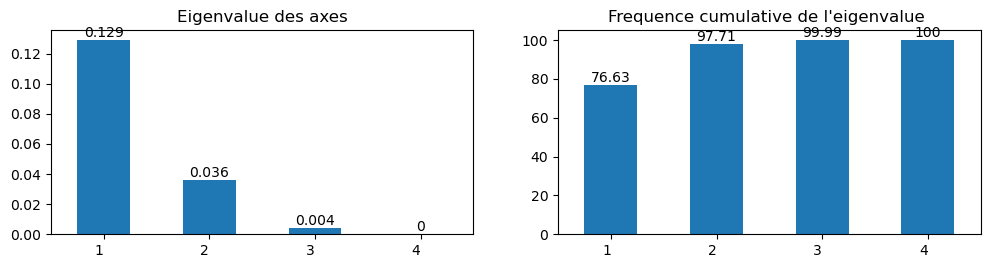

In [13]:
eig = pd.DataFrame(afc.eig_)

r1 = round(eig.iloc[0], 3)
r2 = round(eig.iloc[2], 2)
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,3))

ax1 = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
ax2 = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue ")


ax1.bar_label(ax1.containers[0])
ax2.bar_label(ax2.containers[0])


# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

NB: la valeur propre des axes (eigenvalue) est la valeur de la variance exprimée par ce axe. Il s'agit donc d'une portion du phi-2, i.e. du chi-2 divisé par le nombre d'individus de la population. 100% de la variance équivaut au phi-2.
<br/>

### Distances des lignes / des colonnes

In [14]:
# Calcul des profils des lignes
prof_lig = np.apply_along_axis(arr=D.values,axis=1,
                               func1d=lambda x:x/np.sum(x))
# Calul du profil marginal correspondant
# Cf. ligne grisée de Figure 100, Rakotomalala, 2020
tot_col = ddf.loc['Total'][:5]
prof_marg_lig = tot_col/np.sum(tot_col)

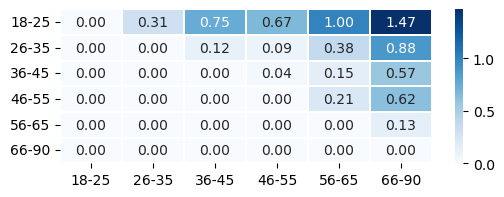

In [15]:
### Distance entre paires de modalités lignes,
# calculée sur la base des valeurs dans la note précédente

fig, ax = plt.subplots(figsize=(6,2))

distPairesLig = np.zeros(shape=(prof_lig.shape[0],prof_lig.shape[0]))
#double boucle
for i in range(prof_lig.shape[0]):
    for j in range(i+1,prof_lig.shape[0]):
        distPairesLig[i,j] = np.sum((prof_lig[i,:]-prof_lig[j,:])**2/prof_marg_lig)

sns.heatmap(distPairesLig,vmin=0,vmax=np.max(distPairesLig),linewidth=0.1,cmap=
'Blues',xticklabels=D.index,yticklabels=D.index,
fmt=".2f", annot=True)


### ATTENTION: plus la couleur est foncée, plus la distance est grande
plt.show()

In [16]:
# Profil marginal des colonnes
tot_lig = np.sum(D.values,axis=1)
prof_marg_col = tot_lig/np.sum(tot_lig)

# Tableau des profils colonnes
prof_col = np.apply_along_axis(arr=D.values,axis=0,
                               func1d=lambda x:x/np.sum(x))
#print(pd.DataFrame(prof_col,index=D.index,columns=D.columns))
### Transposer pour garder la structure du code Python des lignes 
t_prof_col = prof_col.T

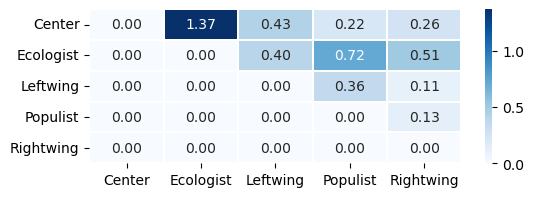

In [17]:
### Distance entre paires de modalités colonnes,
# calculée sur la base des valeurs précédentes  

fig, ax = plt.subplots(figsize=(6,2))


distPairesCol = np.zeros(shape=(t_prof_col.shape[0],
                                t_prof_col.shape[0]))
#double boucle
for i in range(t_prof_col.shape[0]-1):
    for j in range(i+1,t_prof_col.shape[0]):        
        distPairesCol[i,j] = np.sum((t_prof_col[i,:]-t_prof_col[j,:])**2/prof_marg_col)
#distPairesLig[j,i] = distPairesLig[i,j]
#affichage
#print(pd.DataFrame(distPairesLig,index=D.index,columns=D.index))

sns.heatmap(distPairesCol,vmin=0,vmax=np.max(distPairesCol),
            linewidth=0.1,cmap='Blues',xticklabels=D.columns,
            yticklabels=D.columns, 
fmt=".2f", annot=True)

plt.show()

### Graphiques et interprétation du premier plan factoriel

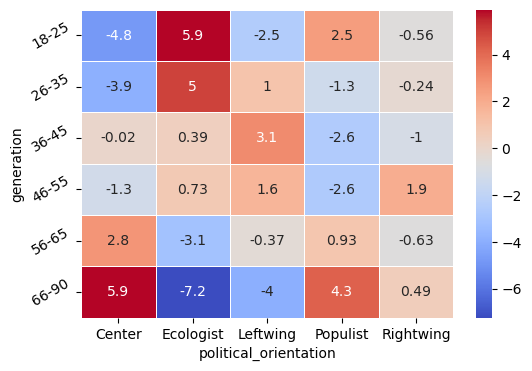

In [18]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


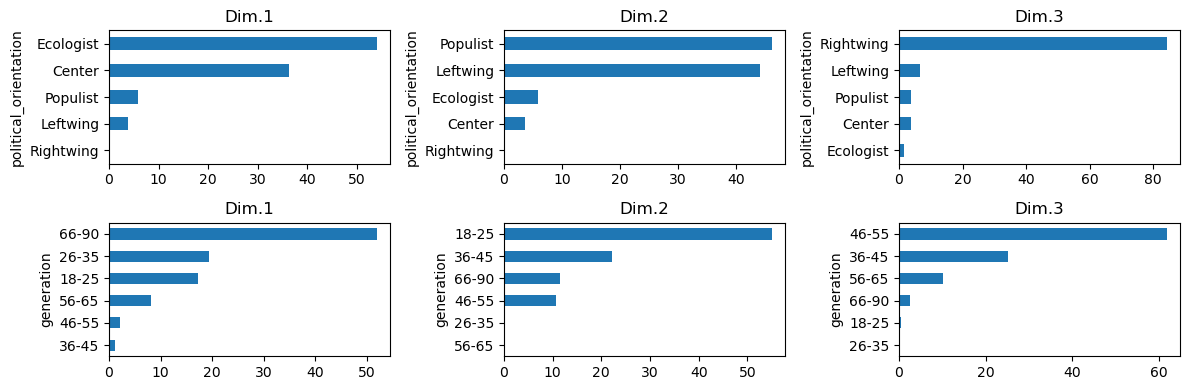

In [19]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()


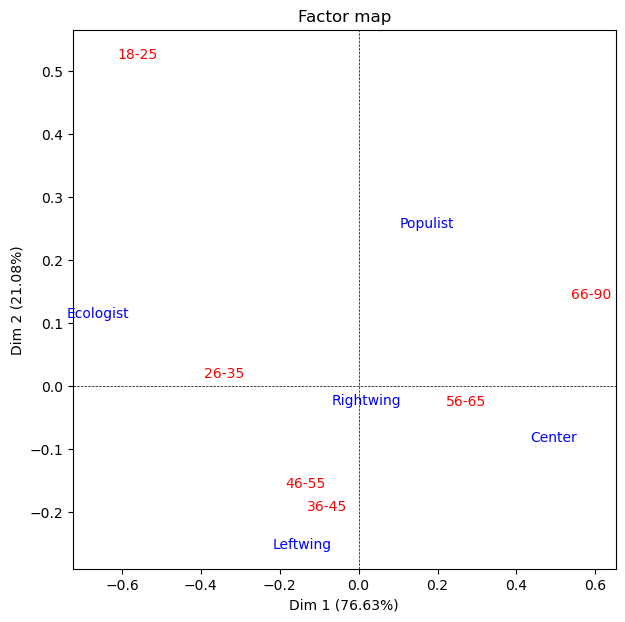

In [20]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

### Représenter l'autre plan factoriel

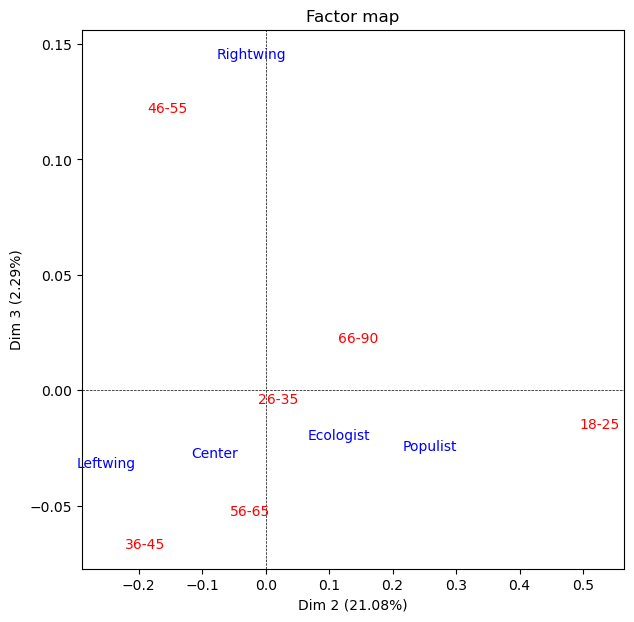

In [21]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(7,7))

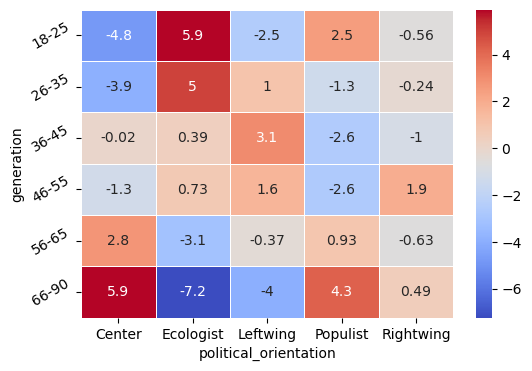

In [22]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


---------

## Genre et orientation politique

In [23]:
X = "gender"
Y = "political_orientation"  # "0"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing,Total
gender,,,,,,
Female,157,152,189,198,145,841
Male,158,107,208,191,105,769
Other,12,12,27,28,11,90
Total,327,271,424,417,261,1700


In [24]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing
gender,,,,,
Female,157,152,189,198,145
Male,158,107,208,191,105
Other,12,12,27,28,11


In [25]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 3 , 5 ), effectif: 1700 , nombre max. facteurs: 2


In [26]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D, method='cramer')
print('Cramer: ', vc)

Chi2 : 17.494637521537534 , dof : 8
p-value : 0.02535136059780224
phi2 = inertie (variance totale) : 0.010290963247963256
Cramer:  0.07173201254657245


In [27]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'),
   row_labels=Index(['Female', 'Male', 'Other'], dtype='object', name='gender'))

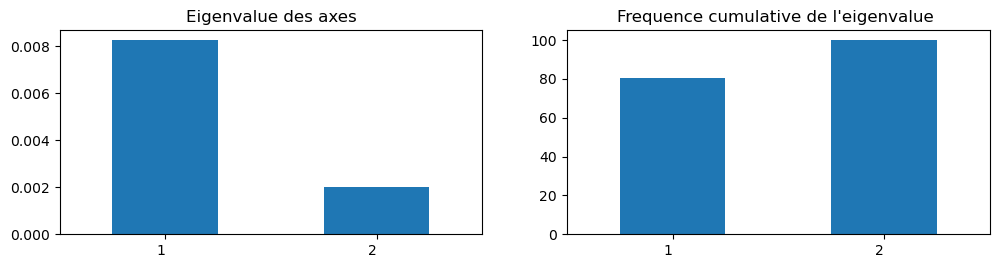

In [28]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,3))

r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Commentaire

Pas la peine de poursuivre, seulement deux modalités pour la variable genre, et un seul axe factoriel. 

Une analyse bivariée avec test du chi-2 suffit.

--------

## Orientation politique et fréquence de lecture du journal

In [29]:
c_obs.head(2)

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,24147,daily,Rightwing,115,36-45,12000-299999,114-123
2,81,Male,47296,daily,Rightwing,0,66-90,12000-299999,0-5


In [30]:
X = "political_orientation"  # "0"
Y = "newspaper_reading_frequency"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

newspaper_reading_frequency,3-4 days a week,daily,rarely,sometimes,week-end,Total
political_orientation,,,,,,
Center,169,65,0,46,47,327
Ecologist,0,0,95,76,100,271
Leftwing,137,101,66,27,93,424
Populist,0,0,174,116,127,417
Rightwing,180,78,0,1,2,261
Total,486,244,335,266,369,1700


In [31]:
ddf = ddf[['rarely', 'rarely', 'week-end', '3-4 days a week', 'daily','Total']]
ddf.columns = ['0 très rar', '1 de temps', '2 week-end', '3 trois-quatre', '4 tous les','Total']
ddf

,0 très rar,1 de temps,2 week-end,3 trois-quatre,4 tous les,Total
political_orientation,,,,,,
Center,0,0,47,169,65,327
Ecologist,95,95,100,0,0,271
Leftwing,66,66,93,137,101,424
Populist,174,174,127,0,0,417
Rightwing,0,0,2,180,78,261
Total,335,335,369,486,244,1700


In [32]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

,0 très rar,1 de temps,2 week-end,3 trois-quatre,4 tous les
political_orientation,,,,,
Center,0,0,47,169,65
Ecologist,95,95,100,0,0
Leftwing,66,66,93,137,101
Populist,174,174,127,0,0
Rightwing,0,0,2,180,78


In [33]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 5 , 5 ), effectif: 1769 , nombre max. facteurs: 4


In [34]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 1197.1050938378512 , dof : 16
p-value : 6.2275537711273404e-245
phi2 = inertie (variance totale) : 0.6767128851542403
Cramer:  0.4159994337671193


In [35]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['0 très rar', '1 de temps', '2 week-end', '3 trois-quatre',
       '4 tous les'],
      dtype='object'),
   row_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'))

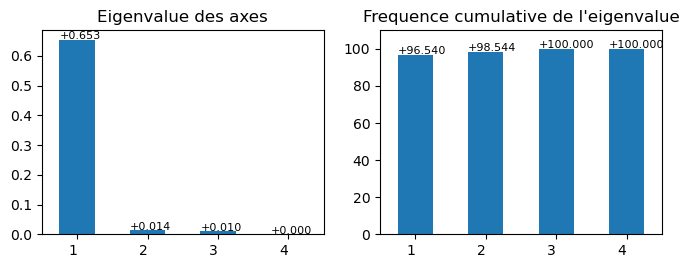

In [36]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

### https://stackoverflow.com/questions/25447700/annotate-bars-with-values-on-pandas-bar-plots
aa = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
for p in aa.patches:
    b = p.get_bbox()
    # print(b)
    val = "{:+.3f}".format(b.y1 + b.y0)    
    # print(b.x1)    
    aa.annotate(val, (b.x0 , b.y1* 1.005), size=8)
plt.margins(y = 0.1)

bb = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue")

for container in bb.containers:
    for p in bb.patches:
        b = p.get_bbox()
        # print(b)
        val = "{:+.3f}".format(b.y1 + b.y0)    
        # print(b.x1)    
        bb.annotate(val, (b.x0, b.y1* 1.005), size=8)


plt.margins(y = 0.1)
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Distances des lignes / des colonnes

In [37]:
# Calcul des profils des lignes
prof_lig = np.apply_along_axis(arr=D.values,axis=1,
                               func1d=lambda x:x/np.sum(x))
# Calul du profil marginal correspondant
# Cf. ligne grisée de Figure 100, Rakotomalala, 2020
tot_col = ddf.loc['Total'][:5]
prof_marg_lig = tot_col/np.sum(tot_col)

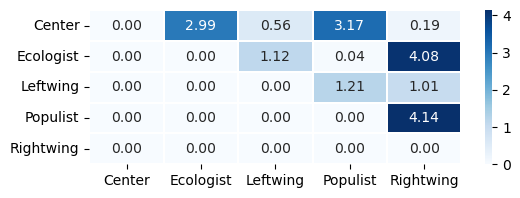

In [38]:
### Distance entre paires de modalités lignes,
# calculée sur la base des valeurs dans la note précédente

fig, ax = plt.subplots(figsize=(6,2))

distPairesLig = np.zeros(shape=(prof_lig.shape[0],prof_lig.shape[0]))
#double boucle
for i in range(prof_lig.shape[0]):
    for j in range(i+1,prof_lig.shape[0]):
        distPairesLig[i,j] = np.sum((prof_lig[i,:]-prof_lig[j,:])**2/prof_marg_lig)

sns.heatmap(distPairesLig,vmin=0,vmax=np.max(distPairesLig),linewidth=0.1,cmap=
'Blues',xticklabels=D.index,yticklabels=D.index,
fmt=".2f", annot=True)


### ATTENTION: plus la couleur est foncée, plus la distance est grande
plt.show()

In [39]:
# Profil marginal des filières (colonnes)
tot_lig = np.sum(D.values,axis=1)
prof_marg_col = tot_lig/np.sum(tot_lig)

# Tableau des profils colonnes
prof_col = np.apply_along_axis(arr=D.values,axis=0,
                               func1d=lambda x:x/np.sum(x))
#print(pd.DataFrame(prof_col,index=D.index,columns=D.columns))
### Transposer pour garder la structure du code Python des lignes 
t_prof_col = prof_col.T

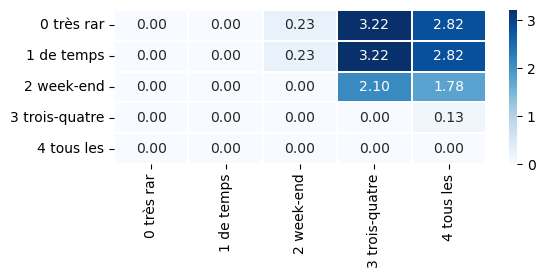

In [40]:
### Distance entre paires de modalités colonnes,
# calculée sur la base des valeurs précédentes  

fig, ax = plt.subplots(figsize=(6,2))


distPairesCol = np.zeros(shape=(t_prof_col.shape[0],
                                t_prof_col.shape[0]))
#double boucle
for i in range(t_prof_col.shape[0]-1):
    for j in range(i+1,t_prof_col.shape[0]):        
        distPairesCol[i,j] = np.sum((t_prof_col[i,:]-t_prof_col[j,:])**2/prof_marg_col)
#distPairesLig[j,i] = distPairesLig[i,j]
#affichage
#print(pd.DataFrame(distPairesLig,index=D.index,columns=D.index))

sns.heatmap(distPairesCol,vmin=0,vmax=np.max(distPairesCol),
            linewidth=0.1,cmap='Blues',xticklabels=D.columns,
            yticklabels=D.columns, 
fmt=".2f", annot=True)

plt.show()

### Graphiques et interprétation du premier plan factoriel

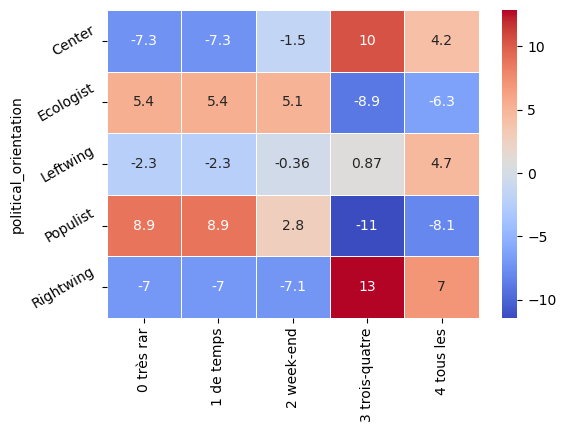

In [41]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


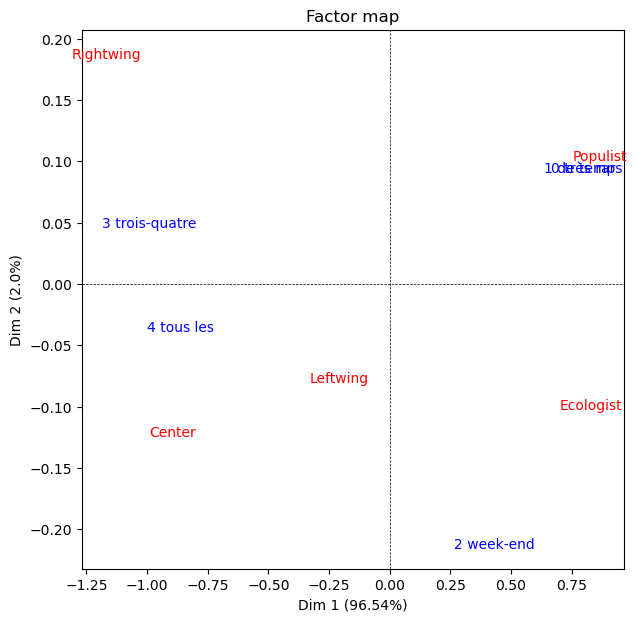

In [42]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

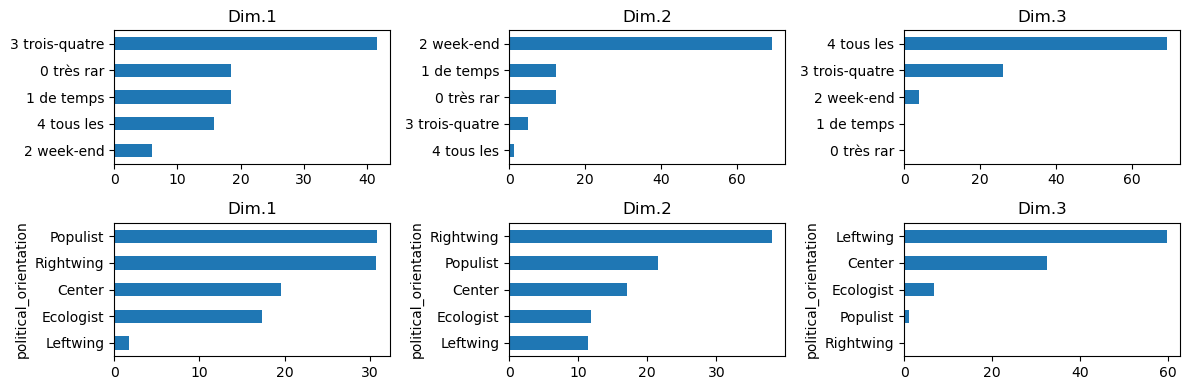

In [43]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()


## Classe de revenu et orientation politique

In [44]:
c_obs.head(2)

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,24147,daily,Rightwing,115,36-45,12000-299999,114-123
2,81,Male,47296,daily,Rightwing,0,66-90,12000-299999,0-5


In [45]:
X = "political_orientation"  # "0"
Y = "classe_revenu"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

classe_revenu,0-2999,10000-11999,12000-299999,3000-4499,4500-5999,6000-7999,8000-9999,Total
political_orientation,,,,,,,,
Center,0,68,166,0,3,42,48,327
Ecologist,89,0,0,87,49,44,2,271
Leftwing,33,72,30,48,67,102,72,424
Populist,81,0,0,153,93,73,17,417
Rightwing,0,6,252,0,0,0,3,261
Total,203,146,448,288,212,261,142,1700


In [46]:
ddf = ddf[['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999', '10000-11999', '12000-299999','Total']]
ddf

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999,Total
political_orientation,,,,,,,,
Center,0,0,3,42,48,68,166,327
Ecologist,89,87,49,44,2,0,0,271
Leftwing,33,48,67,102,72,72,30,424
Populist,81,153,93,73,17,0,0,417
Rightwing,0,0,0,0,3,6,252,261
Total,203,288,212,261,142,146,448,1700


In [47]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999
political_orientation,,,,,,,
Center,0,0,3,42,48,68,166
Ecologist,89,87,49,44,2,0,0
Leftwing,33,48,67,102,72,72,30
Populist,81,153,93,73,17,0,0
Rightwing,0,0,0,0,3,6,252


In [48]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 5 , 7 ), effectif: 1700 , nombre max. facteurs: 4


In [49]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 1672.8903108001236 , dof : 24
p-value : 0.0
phi2 = inertie (variance totale) : 0.9840531240000727
Cramer:  0.3925378560800041


In [50]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999',
       '10000-11999', '12000-299999'],
      dtype='object', name='classe_revenu'),
   row_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'))

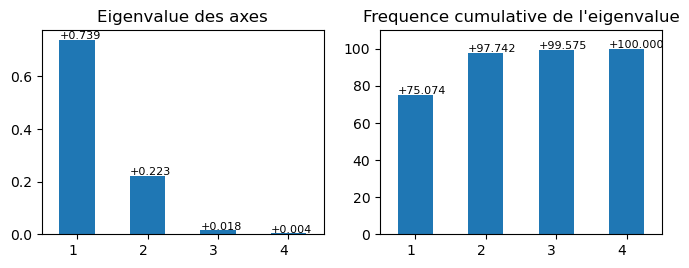

In [51]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

### https://stackoverflow.com/questions/25447700/annotate-bars-with-values-on-pandas-bar-plots
aa = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
for p in aa.patches:
    b = p.get_bbox()
    # print(b)
    val = "{:+.3f}".format(b.y1 + b.y0)    
    # print(b.x1)    
    aa.annotate(val, (b.x0 , b.y1* 1.005), size=8)
plt.margins(y = 0.1)

bb = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue")

for container in bb.containers:
    for p in bb.patches:
        b = p.get_bbox()
        # print(b)
        val = "{:+.3f}".format(b.y1 + b.y0)    
        # print(b.x1)    
        bb.annotate(val, (b.x0, b.y1* 1.005), size=8)


plt.margins(y = 0.1)
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Graphiques et interprétation du premier plan factoriel

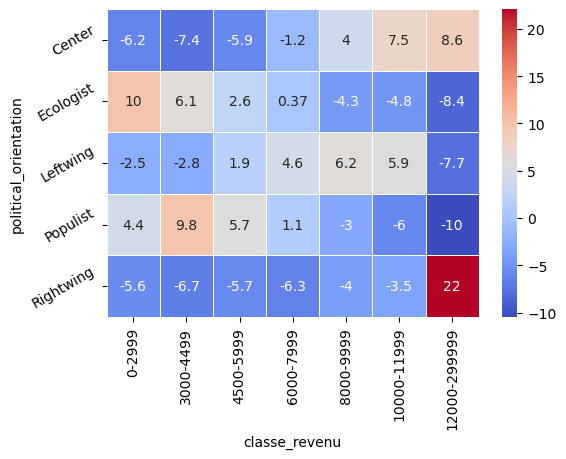

In [52]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


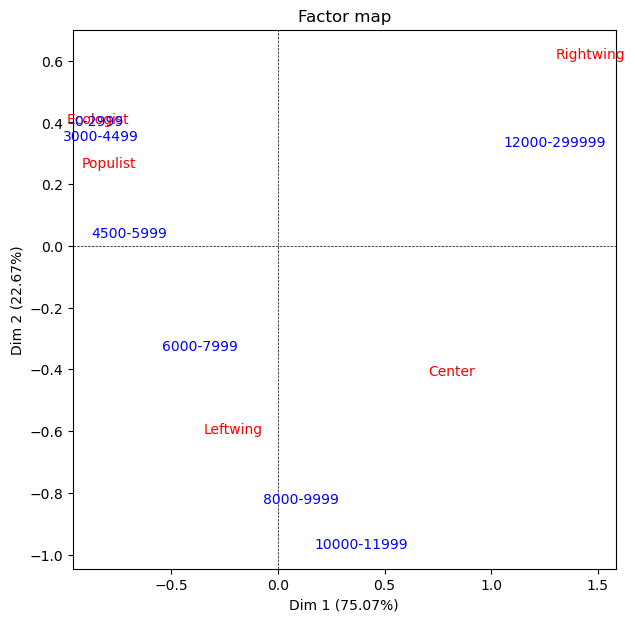

In [53]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

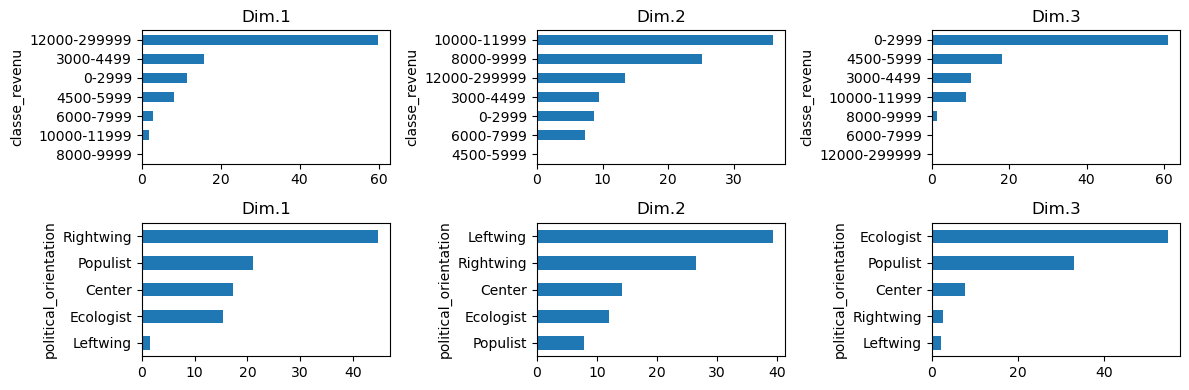

In [54]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()


## Classe de revenu et de participation aux réseaux sociaux digitaus

In [55]:
c_obs.head(2)

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,24147,daily,Rightwing,115,36-45,12000-299999,114-123
2,81,Male,47296,daily,Rightwing,0,66-90,12000-299999,0-5


In [56]:
X = "classe_media"  # "0"
Y = "classe_revenu"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

classe_revenu,0-2999,10000-11999,12000-299999,3000-4499,4500-5999,6000-7999,8000-9999,Total
classe_media,,,,,,,,
0-5,3,6,59,34,25,32,13,172
104-113,13,22,42,29,27,32,13,178
114-123,15,20,33,32,19,26,20,165
124-133,25,11,50,26,21,36,10,179
134-144,25,12,37,34,19,25,13,165
145-161,28,10,40,25,26,22,11,162
162-256,70,6,32,32,11,7,10,168
33-88,8,32,43,27,21,20,27,178
6-32,7,6,70,23,24,28,10,168


In [57]:
ddf = ddf[['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999', '10000-11999', '12000-299999','Total']]
ddf

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999,Total
classe_media,,,,,,,,
0-5,3,34,25,32,13,6,59,172
104-113,13,29,27,32,13,22,42,178
114-123,15,32,19,26,20,20,33,165
124-133,25,26,21,36,10,11,50,179
134-144,25,34,19,25,13,12,37,165
145-161,28,25,26,22,11,10,40,162
162-256,70,32,11,7,10,6,32,168
33-88,8,27,21,20,27,32,43,178
6-32,7,23,24,28,10,6,70,168


In [58]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999
classe_media,,,,,,,
0-5,3,34,25,32,13,6,59
104-113,13,29,27,32,13,22,42
114-123,15,32,19,26,20,20,33
124-133,25,26,21,36,10,11,50
134-144,25,34,19,25,13,12,37
145-161,28,25,26,22,11,10,40
162-256,70,32,11,7,10,6,32
33-88,8,27,21,20,27,32,43
6-32,7,23,24,28,10,6,70


In [59]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 10 , 7 ), effectif: 1700 , nombre max. facteurs: 6


In [60]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 299.2571398019213 , dof : 54
p-value : 1.1067967891493422e-35
phi2 = inertie (variance totale) : 0.176033611648189
Cramer:  0.2036567085154009


In [61]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999',
       '10000-11999', '12000-299999'],
      dtype='object', name='classe_revenu'),
   row_labels=Index(['0-5', '104-113', '114-123', '124-133', '134-144', '145-161', '162-256',
       '33-88', '6-32', '89-103'],
      dtype='object', name='classe_media'))

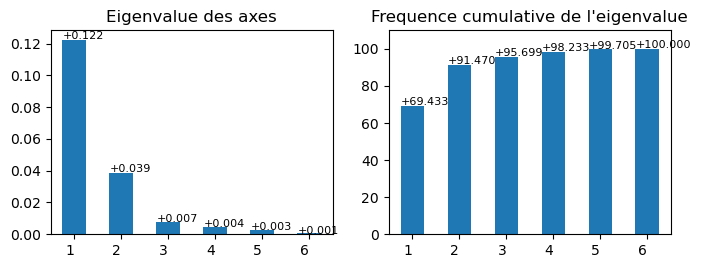

In [62]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

### https://stackoverflow.com/questions/25447700/annotate-bars-with-values-on-pandas-bar-plots
aa = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
for p in aa.patches:
    b = p.get_bbox()
    # print(b)
    val = "{:+.3f}".format(b.y1 + b.y0)    
    # print(b.x1)    
    aa.annotate(val, (b.x0 , b.y1* 1.005), size=8)
plt.margins(y = 0.1)

bb = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue")

for container in bb.containers:
    for p in bb.patches:
        b = p.get_bbox()
        # print(b)
        val = "{:+.3f}".format(b.y1 + b.y0)    
        # print(b.x1)    
        bb.annotate(val, (b.x0, b.y1* 1.005), size=8)


plt.margins(y = 0.1)
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Graphiques et interprétation du premier plan factoriel

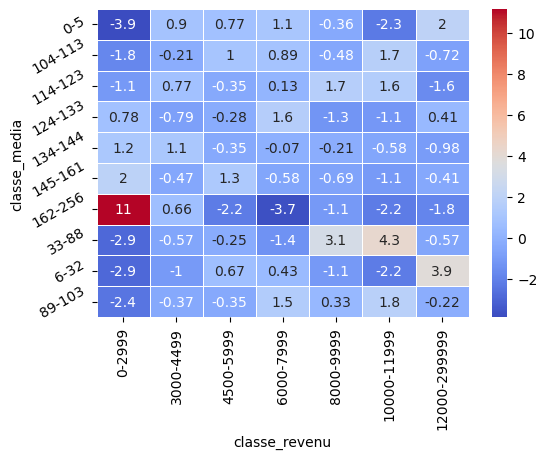

In [63]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


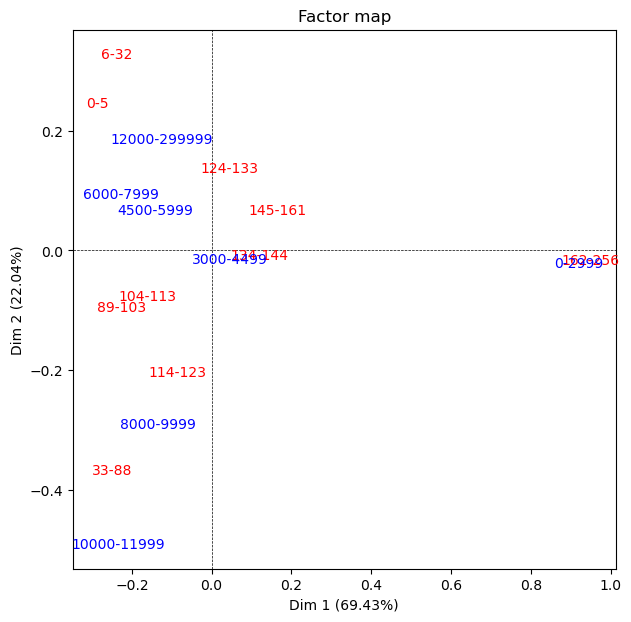

In [64]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

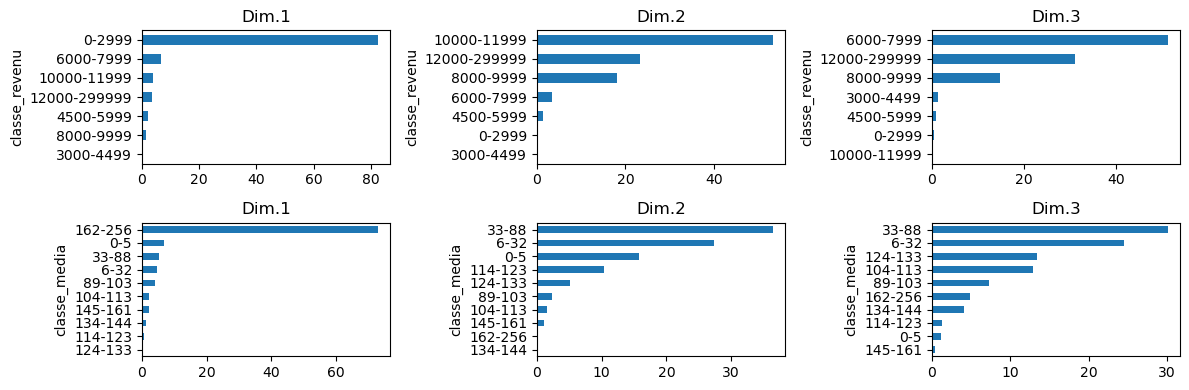

In [65]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()
